# 02 · Probes, ensembling, and two results that went the wrong way

Lightweight MLP heads trained on the cached features, then every way of combining them.

The headline is 97.16%. The interesting part is what *didn't* work: a trained fusion head
that lost to arithmetic, and a third backbone that earned no place in the ensemble despite
being the one predicted to help most.

In [1]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REPORTS = ROOT / "artifacts" / "reports"

# Chart palette, validated for the lightness band, chroma floor, colour-vision
# separation and contrast. The interface accents fail as data marks: they sit
# too light and drop under 3:1 against the page. Order matters — green beside
# amber fails deuteranope separation, so teal sits between them.
INK, DIM = "#0b0b0f", "#4b4b55"
C = ["#e62429", "#1b4ce0", "#c07708", "#0e8fa3", "#16a34a"]

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": DIM, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": DIM, "ytick.color": DIM,
    "axes.grid": True, "grid.color": "#e6e4dc", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "legend.frameon": False,
})

## Single heads

In [2]:
probes = []
for name in ["siglip_so400m", "eva02_large", "dinov2_large", "fusion_siglip_eva02"]:
    p = REPORTS / f"probe_{name}.json"
    if p.exists():
        probes.append(json.loads(p.read_text()))

df = pd.DataFrame(probes)[["name", "params", "val_top1", "test_top1", "test_top5", "minutes"]]
df["params"] = (df["params"] / 1e6).round(2)
df.sort_values("test_top1", ascending=False).reset_index(drop=True)

,name,params,val_top1,test_top1,test_top5,minutes
0,fusion_siglip_eva02,3.97,95.776,96.966,99.481,21.87
1,siglip_so400m,1.93,95.644,96.828,99.533,3.75
2,eva02_large,1.73,93.135,95.529,99.295,6.90
3,dinov2_large,1.73,92.640,94.871,99.196,0.75


**SigLIP beats EVA-02 by 1.3 points as a frozen extractor.** SigLIP-SO400M was pretrained
on web images *with captions*, and captions name dishes — so its frozen features already
encode food semantics. EVA-02 is supervised on ImageNet-22k, whose food coverage is
narrower. For frozen probing, pretraining data dominates architecture.

This says nothing about fine-tuning, where EVA-02 can reshape its features. That is
notebook 06.

## The ablation

In [3]:
ens = json.loads((REPORTS / "ensemble.json").read_text())
rows = pd.DataFrame([{
    "members": " + ".join(r["members"]),
    "method": r["method"],
    "test_top1": r["test_top1"],
    "test_top5": r["test_top5"],
} for r in ens["results"]])
rows.head(12)

,members,method,test_top1,test_top5
0,siglip_so400m + eva02_large,prob average (uniform),97.156,99.644
1,siglip_so400m + eva02_large,prob average (val-tuned),97.141,99.659
2,siglip_so400m + eva02_large,logit average (uniform),97.105,99.640
3,siglip_so400m + eva02_large + dinov2_large,prob average (uniform),97.093,99.675
4,siglip_so400m + eva02_large + dinov2_large,prob average (val-tuned),97.081,99.671
5,siglip_so400m + eva02_large + dinov2_large,logit average (uniform),97.065,99.707
6,siglip_so400m + dinov2_large,prob average (val-tuned),97.018,99.655
7,siglip_so400m + dinov2_large,logit average (uniform),96.947,99.651
8,siglip_so400m + dinov2_large,prob average (uniform),96.907,99.659
9,siglip_so400m,solo,96.828,99.533


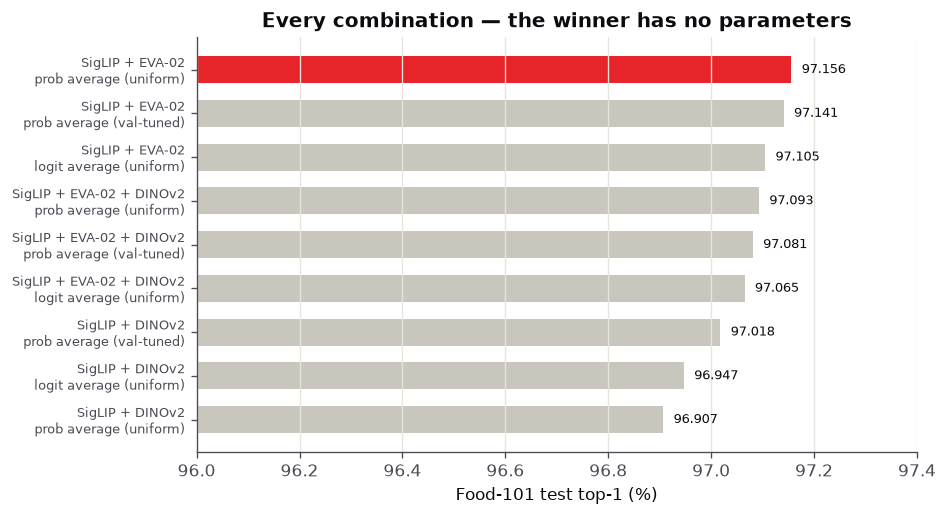

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.4))
top = rows.head(9).iloc[::-1]
labels = [f"{m}\n{me}" for m, me in zip(top["members"], top["method"])]
colors = [C[0] if v == rows["test_top1"].max() else "#c9c6bd" for v in top["test_top1"]]
bars = ax.barh(range(len(top)), top["test_top1"], color=colors, height=0.62)
ax.set_yticks(range(len(top)))
ax.set_yticklabels([l.replace("siglip_so400m", "SigLIP").replace("eva02_large", "EVA-02")
                    .replace("dinov2_large", "DINOv2") for l in labels], fontsize=7.5)
ax.set_xlim(96.0, 97.4)
ax.set_xlabel("Food-101 test top-1 (%)")
ax.set_title("Every combination — the winner has no parameters")
for b, v in zip(bars, top["test_top1"]):
    ax.text(v + 0.02, b.get_y() + b.get_height()/2, f"{v:.3f}", va="center", fontsize=8)
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

## Is the difference real?

A few tenths of a point on 25,250 images is well inside the range where two systems differ
by luck. Only the images where two systems **disagree** carry information about which is
better, which is exactly what an exact McNemar test uses.

In [5]:
for label, m in ens["mcnemar"].items():
    verdict = "significant" if m["significant"] else "NOT significant"
    print(f"{label}\n  p = {m['p']:.6g}  →  {verdict}")
    print(f"  discordant pairs: {m['a_only']} / {m['b_only']}\n")

prob average (uniform) siglip_so400m+eva02_large vs best solo siglip_so400m
  p = 3e-06  →  significant
  discordant pairs: 198 / 115

prob average vs logit average (all members)
  p = 0.546713  →  NOT significant
  discordant pairs: 53 / 46



**A 3.97M-parameter gated fusion head, trained for 21.9 minutes, did not significantly beat
its own best single input.** A parameter-free 50/50 average of the same two probes did — and
beat the fusion head as well.

The lesson is not that learned fusion never works. It is that on two heavily correlated
members, the thing being learned is a weighting that a constant already gets right, and the
extra capacity buys variance rather than signal.

## Why the gains are small

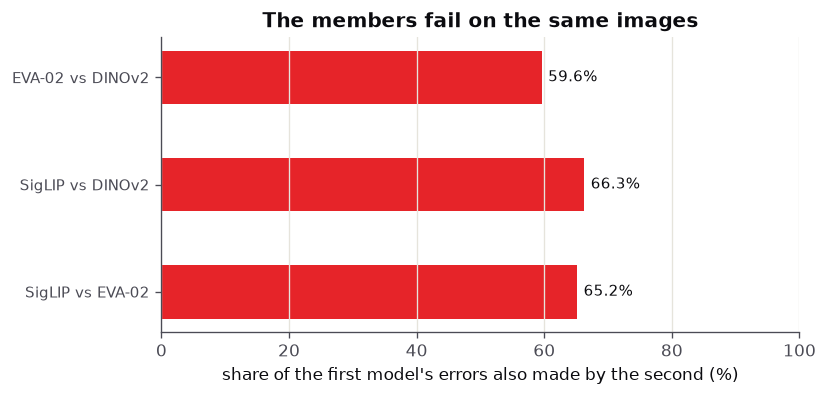

oracle (any member correct)  98.301%
all members wrong            1.699%


In [6]:
ag = ens["agreement"]
fig, ax = plt.subplots(figsize=(7, 3.4))
pairs = list(ag["pairs"].items())
names = [p.replace("siglip_so400m", "SigLIP").replace("eva02_large", "EVA-02")
          .replace("dinov2_large", "DINOv2") for p, _ in pairs]
vals = [v["shared_error_rate"] for _, v in pairs]
ax.barh(range(len(pairs)), vals, color=C[0], height=0.5)
ax.set_yticks(range(len(pairs))); ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel("share of the first model's errors also made by the second (%)")
ax.set_title("The members fail on the same images")
ax.set_xlim(0, 100); ax.grid(axis="y", visible=False)
for i, v in enumerate(vals):
    ax.text(v + 1, i, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout(); plt.show()

print(f"oracle (any member correct)  {ag['oracle_top1']}%")
print(f"all members wrong            {ag['all_wrong']}%")

**DINOv2 was predicted to be the least correlated member and is the most.** It is the only
self-supervised backbone here, so its errors were expected to be independent of the
caption-supervised and label-supervised ones. Instead 66.3% of SigLIP's errors are shared
with it — a higher overlap than with EVA-02.

Adding it made the three-way average *worse* than the pair (97.09 against 97.16, McNemar
p = 0.312, so not a significant loss either). A weight search on validation independently
pushed its weight down to 0.05.

The oracle sets the ceiling: if a perfect combiner always picked a member that was right,
this would reach 98.30%. Only 1.70% of test images defeat every model — and a good share of
those are Food-101's own label noise.